# Модель Daisyworld - Влияние солнечной активности

**Цель работы:** Исследовать, как изменение солнечной активности влияет
на динамику маргариток и температуру планеты.

## 1. Теоретическое обоснование

В реальном мире солнечная активность не постоянна. Она может меняться
циклически или линейно. В модели Daisyworld мы можем исследовать два сценария:

### Сценарий :ramp (изменение с возвратом)
Солнечная активность сначала растет (шаги 200-400), затем остается постоянной,
а потом снижается (шаги 500-750). Этот сценарий имитирует, например,
циклические изменения активности Солнца.

### Сценарий :change (линейное изменение)
Солнечная активность постоянно растет. Этот сценарий позволяет исследовать
пределы саморегуляции системы.

## 2. Инициализация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"

using Agents
using CairoMakie
using DataFrames
using Statistics

include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

## 3. Определение функций для сбора данных

In [2]:
black(a) = a.breed == :black
white(a) = a.breed == :white
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (Main.black, count)
 (Main.white, count)

Функция для вычисления средней температуры по всей планете

In [3]:
temperature(model) = Statistics.mean(model.temperature)

temperature (generic function with 1 method)

Данные для сбора на уровне модели:
- средняя температура
- текущая солнечная активность

In [4]:
mdata = [temperature, :solar_luminosity]

2-element Vector{Any}:
 temperature (generic function with 1 method)
 :solar_luminosity

## 4. Запуск симуляции со сценарием :ramp

In [5]:
println("="^60)
println("МОДЕЛЬ DAISYWORLD - ВЛИЯНИЕ СОЛНЕЧНОЙ АКТИВНОСТИ")
println("="^60)
println("\n🔄 Сценарий :ramp (циклическое изменение)")

МОДЕЛЬ DAISYWORLD - ВЛИЯНИЕ СОЛНЕЧНОЙ АКТИВНОСТИ

🔄 Сценарий :ramp (циклическое изменение)


Создаем модель со сценарием :ramp

In [6]:
model = daisyworld(solar_luminosity = 1.0, scenario = :ramp, seed=165)

println("   - Начальная солнечная активность: 1.0")
println("   - Сценарий: рост (200-400), затем спад (500-750)")
println("\n⏳ Запуск симуляции на 1000 шагов...")

   - Начальная солнечная активность: 1.0
   - Сценарий: рост (200-400), затем спад (500-750)

⏳ Запуск симуляции на 1000 шагов...


Запускаем симуляцию

In [7]:
agent_df, model_df = run!(model, 1000; adata = adata, mdata = mdata)

println("✅ Симуляция завершена!")

✅ Симуляция завершена!


## 5. Визуализация результатов для сценария :ramp

In [8]:
println("\n📊 Создание составного графика...")


📊 Создание составного графика...


Создаем фигуру с тремя подграфиками

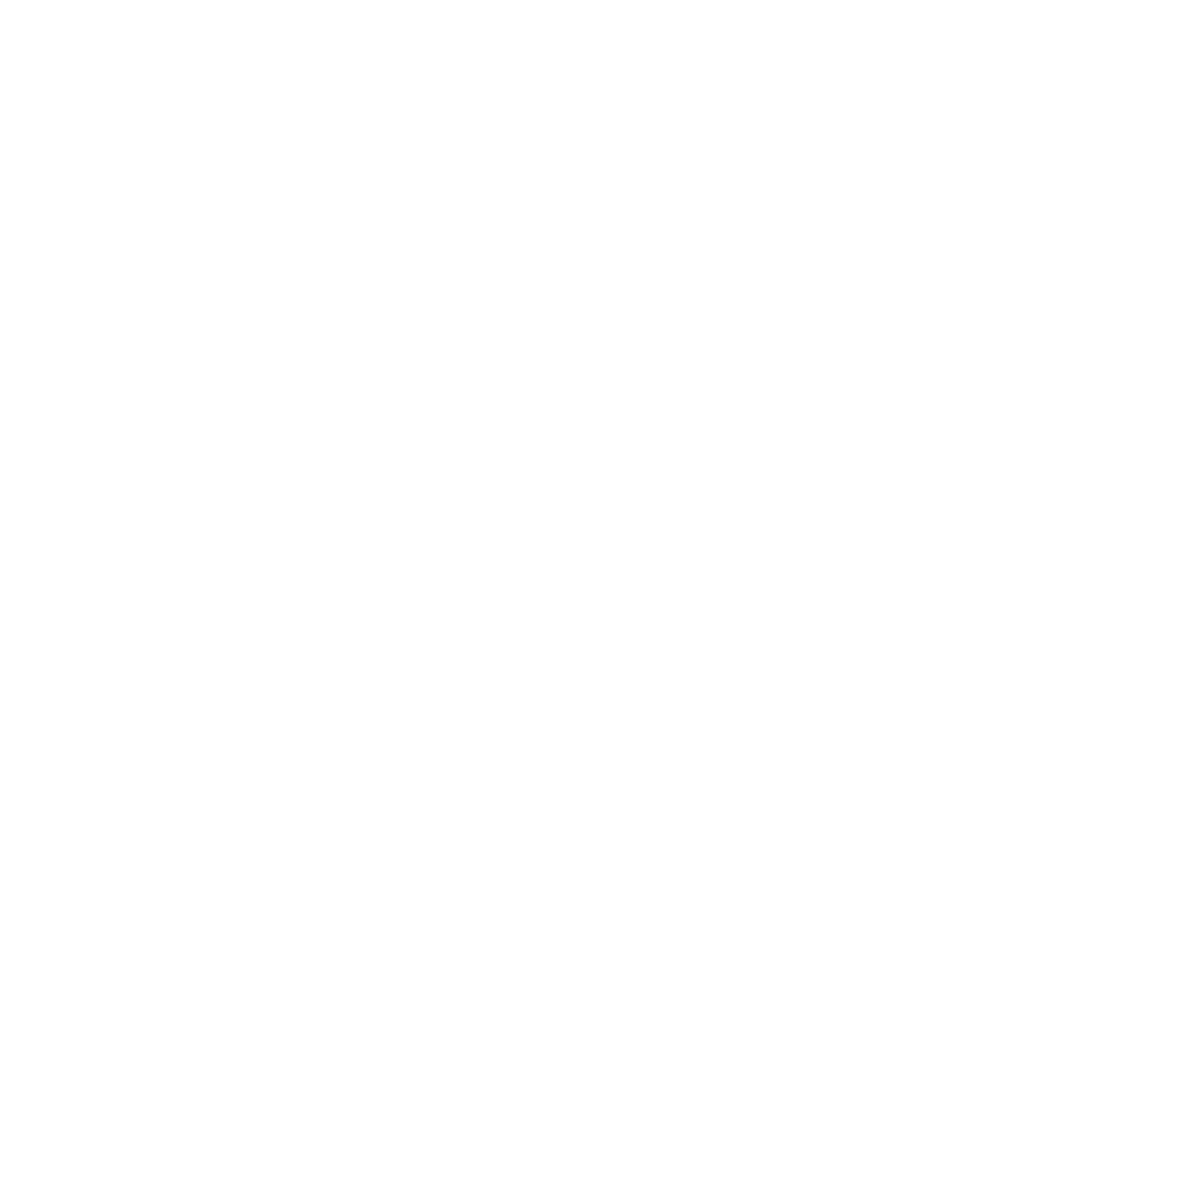

In [9]:
figure = CairoMakie.Figure(size = (600, 600))

### График 1: Численность маргариток

In [10]:
ax1 = figure[1, 1] = Axis(figure,
    ylabel = "Количество маргариток",
    title = "Динамика численности"
)

blackl = lines!(ax1, agent_df[!, :time], agent_df[!, :count_black],
    color = :red, linewidth = 2, label = "Черные")
whitel = lines!(ax1, agent_df[!, :time], agent_df[!, :count_white],
    color = :blue, linewidth = 2, label = "Белые")

Lines{Tuple{Vector{Point{2, Float64}}}}

Добавляем легенду

In [11]:
figure[1, 2] = Legend(figure, [blackl, whitel], ["Черные", "Белые"])

Legend()

### График 2: Средняя температура

In [12]:
ax2 = figure[2, 1] = Axis(figure,
    ylabel = "Средняя температура, °C",
    title = "Изменение температуры"
)
lines!(ax2, model_df[!, :time], model_df[!, :temperature],
    color = :red, linewidth = 2)

Lines{Tuple{Vector{Point{2, Float64}}}}

### График 3: Солнечная активность

In [13]:
ax3 = figure[3, 1] = Axis(figure,
    xlabel = "Время, шаги модели",
    ylabel = "Солнечная активность",
    title = "Изменение солнечной активности"
)
lines!(ax3, model_df[!, :time], model_df[!, :solar_luminosity],
    color = :red, linewidth = 2)

Lines{Tuple{Vector{Point{2, Float64}}}}

Скрываем подписи на верхних графиках (чтобы не загромождать)

In [14]:
for ax in (ax1, ax2)
    ax.xticklabelsvisible = false
end

Сохраняем график

In [15]:
save(plotsdir("daisy_luminosity_ramp.png"), figure)
println("✅ График сохранён: ", plotsdir("daisy_luminosity_ramp.png"))

✅ График сохранён: /afs/.dk.sci.pfu.edu.ru/home/m/v/mvchuvakina/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab03/project/plots/daisy_luminosity_ramp.png


## 6. Запуск симуляции со сценарием :change

In [16]:
println("\n🔄 Сценарий :change (линейный рост)")


🔄 Сценарий :change (линейный рост)


Создаем модель со сценарием :change

In [17]:
model2 = daisyworld(solar_luminosity = 1.0, scenario = :change, seed=165)

println("   - Начальная солнечная активность: 1.0")
println("   - Сценарий: постоянный рост")
println("\n⏳ Запуск симуляции на 1000 шагов...")

   - Начальная солнечная активность: 1.0
   - Сценарий: постоянный рост

⏳ Запуск симуляции на 1000 шагов...


Запускаем симуляцию

In [18]:
agent_df2, model_df2 = run!(model2, 1000; adata = adata, mdata = mdata)

println("✅ Симуляция завершена!")

✅ Симуляция завершена!


Создаем аналогичный график для сценария :change

In [19]:
figure2 = CairoMakie.Figure(size = (600, 600))

ax1b = figure2[1, 1] = Axis(figure2,
    ylabel = "Количество маргариток",
    title = "Динамика численности (линейный рост)"
)

blackl2 = lines!(ax1b, agent_df2[!, :time], agent_df2[!, :count_black],
    color = :red, linewidth = 2, label = "Черные")
whitel2 = lines!(ax1b, agent_df2[!, :time], agent_df2[!, :count_white],
    color = :blue, linewidth = 2, label = "Белые")
figure2[1, 2] = Legend(figure2, [blackl2, whitel2], ["Черные", "Белые"])

ax2b = figure2[2, 1] = Axis(figure2, ylabel = "Средняя температура, °C")
lines!(ax2b, model_df2[!, :time], model_df2[!, :temperature],
    color = :red, linewidth = 2)

ax3b = figure2[3, 1] = Axis(figure2,
    xlabel = "Время, шаги модели",
    ylabel = "Солнечная активность"
)
lines!(ax3b, model_df2[!, :time], model_df2[!, :solar_luminosity],
    color = :red, linewidth = 2)

for ax in (ax1b, ax2b)
    ax.xticklabelsvisible = false
end

save(plotsdir("daisy_luminosity_change.png"), figure2)
println("✅ График сохранён: ", plotsdir("daisy_luminosity_change.png"))

✅ График сохранён: /afs/.dk.sci.pfu.edu.ru/home/m/v/mvchuvakina/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab03/project/plots/daisy_luminosity_change.png


## 7. Сравнительный анализ

In [20]:
println("\n📈 Сравнительный анализ сценариев:")
println("\nСценарий :ramp:")
println("   - Пик численности черных: ", maximum(agent_df[!, :count_black]))
println("   - Пик численности белых: ", maximum(agent_df[!, :count_white]))
println("   - Диапазон температур: ", round(minimum(model_df[!, :temperature]), digits=1),
    " - ", round(maximum(model_df[!, :temperature]), digits=1))

println("\nСценарий :change:")
println("   - Пик численности черных: ", maximum(agent_df2[!, :count_black]))
println("   - Пик численности белых: ", maximum(agent_df2[!, :count_white]))
println("   - Диапазон температур: ", round(minimum(model_df2[!, :temperature]), digits=1),
    " - ", round(maximum(model_df2[!, :temperature]), digits=1))

println("\n📌 Выводы:")
println("   - В сценарии :ramp система успевает адаптироваться к изменениям")
println("   - В сценарии :change при слишком высокой солнечной активности")
println("     маргаритки могут погибнуть (проверьте графики)")
println("\n" * "="^60)


📈 Сравнительный анализ сценариев:

Сценарий :ramp:
   - Пик численности черных: 730
   - Пик численности белых: 900
   - Диапазон температур: 3.6 - 40.3

Сценарий :change:
   - Пик численности черных: 571
   - Пик численности белых: 900
   - Диапазон температур: 3.3 - 172.0

📌 Выводы:
   - В сценарии :ramp система успевает адаптироваться к изменениям
   - В сценарии :change при слишком высокой солнечной активности
     маргаритки могут погибнуть (проверьте графики)

